# Mouse Dynamics — Análise dos Outputs Consolidados

Notebook para análise dos resultados **já consolidados entre as 5 seeds** pelo `consolidar_resultados.py` (pasta `consolidado/`, arquivos `resumo_por_config.csv` e `resumo_por_usuario.csv`).

Diferente da versão anterior, este notebook **não lê mais os JSONs brutos por seed** nem seleciona uma "melhor seed" — todas as métricas aqui já são médias (± desvio padrão) sobre as 5 seeds de cada combinação `classificador x window_size`. Por esse motivo, a seção de melhores parâmetros do Optuna por usuário foi removida (os `best_params` não fazem parte da consolidação, já que agregar hiperparâmetros entre seeds não tem leitura direta).

Todos os gráficos são salvos **individualmente**, um arquivo PDF por figura, na pasta `graficos_pdf/`.

## 0. Setup

In [1]:
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# Tamanhos de fonte dos gráficos (ajuste aqui para mudar todos de uma vez)
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
FS_ANNOT = 10  # ids de usuário anotados nos pontos/linhas
FS_CD = 12     # rótulos dos diagramas de diferença crítica

# Nomes exibidos nos gráficos (siglas em maiúsculo)
CLF_LABELS = {'knn': 'KNN', 'mlp': 'MLP', 'random-forest': 'Random Forest'}
DATASET_LABELS = {'balabit': 'Balabit', 'bogazici': 'Bogazici', 'minecraft': 'Minecraft'}


def clf_label(clf):
    return CLF_LABELS.get(clf, clf)


def ds_label(dataset):
    return DATASET_LABELS.get(dataset, dataset)


def titulo(clf, dataset):
    """Título no padrão 'KNN (Balabit)'."""
    return f"{clf_label(clf)} ({ds_label(dataset)})"


def rotular_classificadores(ax, ordem):
    """Troca os rótulos do eixo x (nomes crus dos classificadores) pelos nomes de exibição."""
    ax.set_xticks(range(len(ordem)))
    ax.set_xticklabels([clf_label(c) for c in ordem])

# Ajuste estes caminhos se necessário — apontam para a pasta de saída
# do consolidar_resultados.py (parâmetro --out)
CONSOLIDADO_DIR = Path('../consolidado')
CONFIG_CSV = CONSOLIDADO_DIR / 'resumo_por_config.csv'
USER_CSV = CONSOLIDADO_DIR / 'resumo_por_usuario.csv'

# Pasta onde cada gráfico é salvo como PDF individual
PDF_DIR = Path('graficos_pdf')
PDF_DIR.mkdir(exist_ok=True)


def save_pdf(fig, name):
    """Salva a figura como um PDF individual em PDF_DIR/{name}.pdf"""
    path = PDF_DIR / f'{name}.pdf'
    fig.savefig(path, bbox_inches='tight')
    print(f'salvo: {path}')


## 1. Carregamento dos dados consolidados

In [2]:
df_config = pd.read_csv(CONFIG_CSV)
df_user = pd.read_csv(USER_CSV)

classifiers = sorted(df_config['classifier'].unique())
datasets = sorted(df_config['dataset'].unique())

print(f"Configs (dataset x classificador x window_size): {len(df_config)}")
print(f"Linhas por usuário (dataset x classificador x window_size x user_id): {len(df_user)}")
print(f"Classificadores : {classifiers}")
print(f"Datasets        : {datasets}")
print(f"Window sizes    : {sorted(df_config['window_size'].unique())}")
df_config.head()


Configs (dataset x classificador x window_size): 48
Linhas por usuário (dataset x classificador x window_size x user_id): 1128
Classificadores : ['knn', 'mlp', 'random-forest']
Datasets        : ['balabit', 'bogazici', 'minecraft']
Window sizes    : [np.int64(10), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250)]


,dataset,classifier,window_size,n_seeds,seeds_usadas,n_users_mean,n_users_consistente,n_users_skipped_mean,mean_score_n,mean_score_mean,...,mean_precision_macro_max,mean_precision_macro_median,mean_precision_macro_cv,mean_recall_macro_n,mean_recall_macro_mean,mean_recall_macro_std,mean_recall_macro_min,mean_recall_macro_max,mean_recall_macro_median,mean_recall_macro_cv
0,balabit,knn,10,5,"001,002,003,004,005",10.0,True,0.0,5,0.654809,...,0.651175,0.650412,0.001604,5,0.667106,0.000940,0.665718,0.667897,0.667637,0.001410
1,balabit,knn,100,5,"001,002,003,004,005",10.0,True,0.0,5,0.676568,...,0.680871,0.675672,0.006385,5,0.689223,0.004099,0.684189,0.693747,0.690820,0.005947
2,balabit,knn,150,5,"001,002,003,004,005",10.0,True,0.0,5,0.684936,...,0.695536,0.684156,0.008994,5,0.694382,0.005974,0.687176,0.703698,0.694246,0.008603
3,balabit,knn,200,5,"001,002,003,004,005",10.0,True,0.0,5,0.681753,...,0.689316,0.684261,0.007200,5,0.691694,0.002986,0.688367,0.694994,0.691394,0.004317
4,balabit,knn,250,5,"001,002,003,004,005",10.0,True,0.0,5,0.690893,...,0.697460,0.694391,0.007694,5,0.698973,0.005713,0.691887,0.704922,0.699901,0.008173


## 2. Melhor configuração por classificador / dataset / window_size

Usa `mean_balanced_score_mean`, já agregado sobre as 5 seeds. Não há mais seleção de "melhor run" (seed) — a comparação é entre configurações (`classificador x window_size`), cada uma já resumida por sua média.

In [3]:
print("Melhor configuração por classificador:")
best_by_clf = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('classifier')
    .first()
    .reset_index()
)
display(best_by_clf[['classifier', 'dataset', 'window_size',
                      'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por classificador:


,classifier,dataset,window_size,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,knn,minecraft,250,0.704200,0.007446,5
1,mlp,bogazici,100,0.709230,0.002562,5
2,random-forest,balabit,250,0.747576,0.004478,5


In [4]:
print("Melhor configuração por dataset:")
best_by_dataset = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('dataset')
    .first()
    .reset_index()
)
display(best_by_dataset[['dataset', 'classifier', 'window_size',
                          'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por dataset:


,dataset,classifier,window_size,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,balabit,random-forest,250,0.747576,0.004478,5
1,bogazici,random-forest,250,0.715573,0.002642,5
2,minecraft,knn,250,0.704200,0.007446,5


In [5]:
print("Melhor configuração por window_size:")
best_by_window = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby('window_size')
    .first()
    .reset_index()
)
display(best_by_window[['window_size', 'dataset', 'classifier',
                         'mean_balanced_score_mean', 'mean_balanced_score_std', 'n_seeds']])


Melhor configuração por window_size:


,window_size,dataset,classifier,mean_balanced_score_mean,mean_balanced_score_std,n_seeds
0,10,balabit,random-forest,0.720421,0.001197,5
1,50,balabit,random-forest,0.735786,0.002169,5
2,100,balabit,random-forest,0.741889,0.002856,5
3,150,balabit,random-forest,0.744499,0.003120,5
4,200,balabit,random-forest,0.742663,0.002380,5
5,250,balabit,random-forest,0.747576,0.004478,5


## 3. Melhor window_size por (classificador, dataset)

Usado como base para os gráficos de comparação entre classificadores nas seções 4 e 5.

In [6]:
best_window_per_clf_ds = (
    df_config.sort_values('mean_balanced_score_mean', ascending=False)
    .groupby(['classifier', 'dataset'])
    .first()
    .reset_index()
)
display(best_window_per_clf_ds[['classifier', 'dataset', 'window_size',
                                 'mean_balanced_score_mean', 'mean_balanced_score_std']])

best_window_lookup = (
    best_window_per_clf_ds.set_index(['classifier', 'dataset'])['window_size'].to_dict()
)


,classifier,dataset,window_size,mean_balanced_score_mean,mean_balanced_score_std
0,knn,balabit,250,0.698973,0.005713
1,knn,bogazici,250,0.661685,0.001071
2,knn,minecraft,250,0.704200,0.007446
3,mlp,balabit,200,0.707746,0.007651
4,mlp,bogazici,100,0.709230,0.002562
5,mlp,minecraft,200,0.617457,0.011535
6,random-forest,balabit,250,0.747576,0.004478
7,random-forest,bogazici,250,0.715573,0.002642
8,random-forest,minecraft,150,0.632331,0.008614


---
## 4. Scatter de usuários: classificador X vs classificador Y

Cada ponto é um usuário; os eixos são o `balanced_score_mean` (já média sobre as 5 seeds) na melhor `window_size` de cada classificador. **Uma figura PDF separada por (dataset, par de classificadores).**

salvo: graficos_pdf\scatter_balabit_knn-vs-mlp.pdf


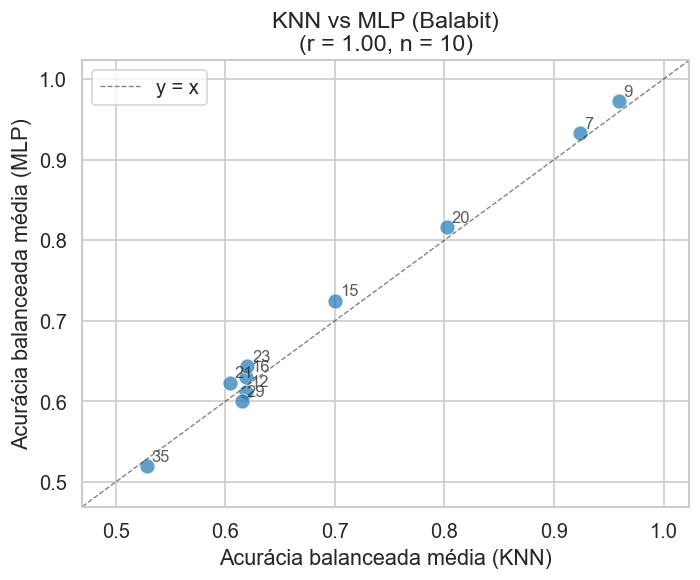

salvo: graficos_pdf\scatter_balabit_knn-vs-random-forest.pdf


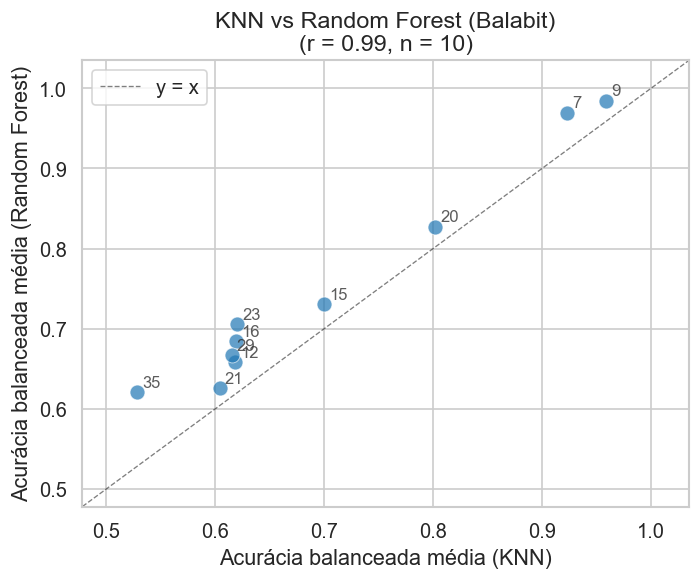

salvo: graficos_pdf\scatter_balabit_mlp-vs-random-forest.pdf


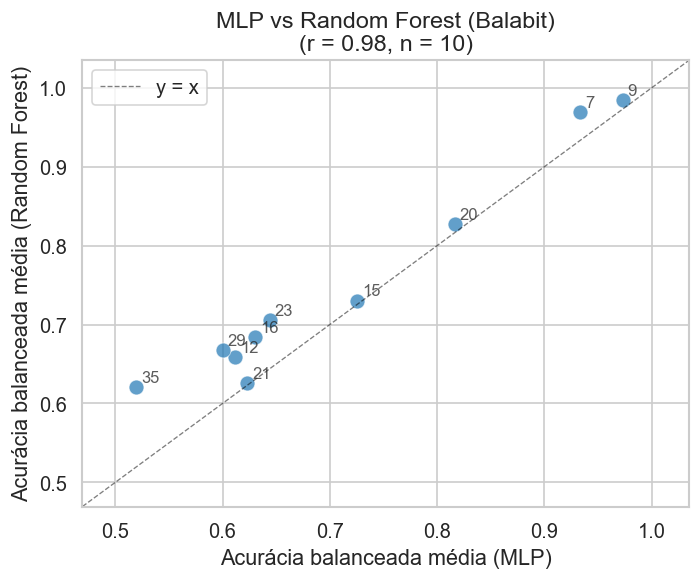

salvo: graficos_pdf\scatter_bogazici_knn-vs-mlp.pdf


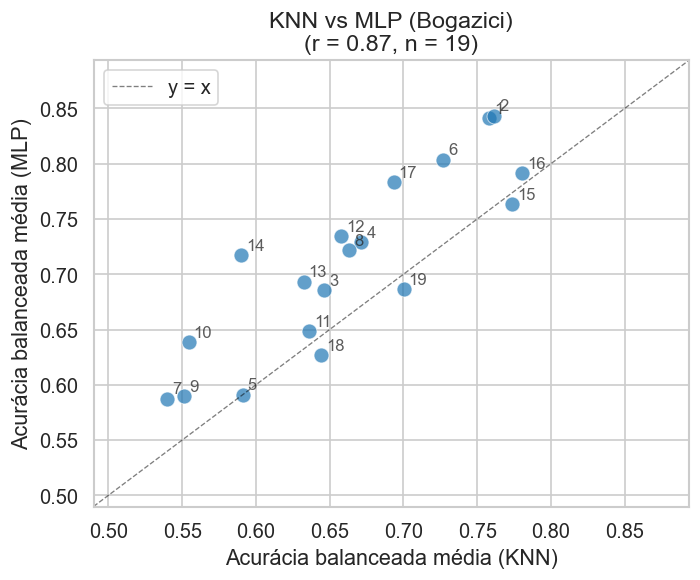

salvo: graficos_pdf\scatter_bogazici_knn-vs-random-forest.pdf


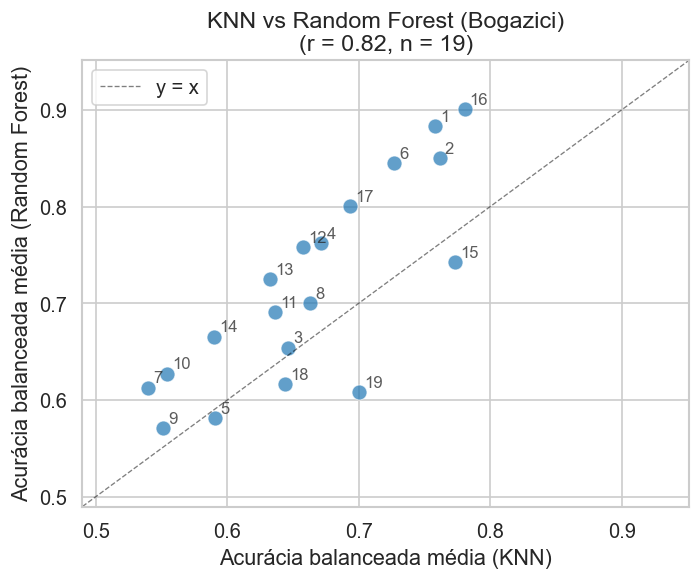

salvo: graficos_pdf\scatter_bogazici_mlp-vs-random-forest.pdf


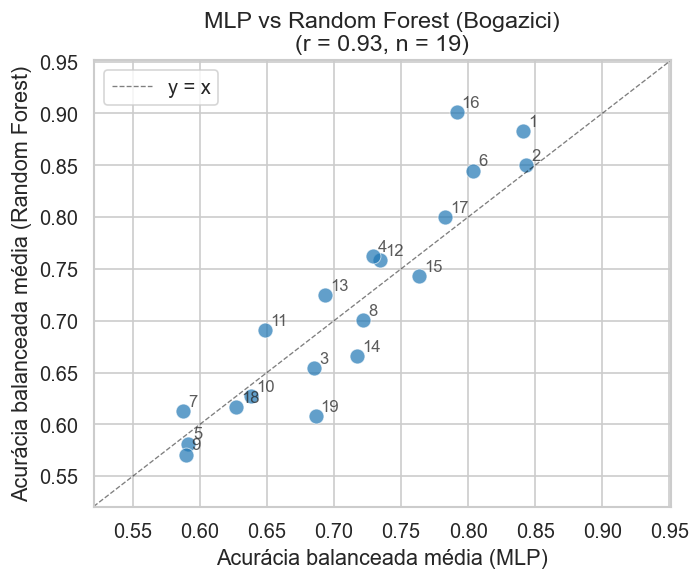

salvo: graficos_pdf\scatter_minecraft_knn-vs-mlp.pdf


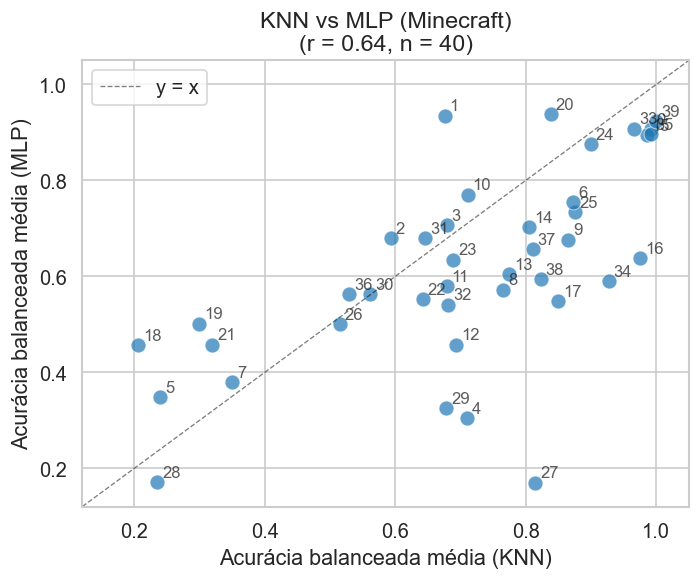

salvo: graficos_pdf\scatter_minecraft_knn-vs-random-forest.pdf


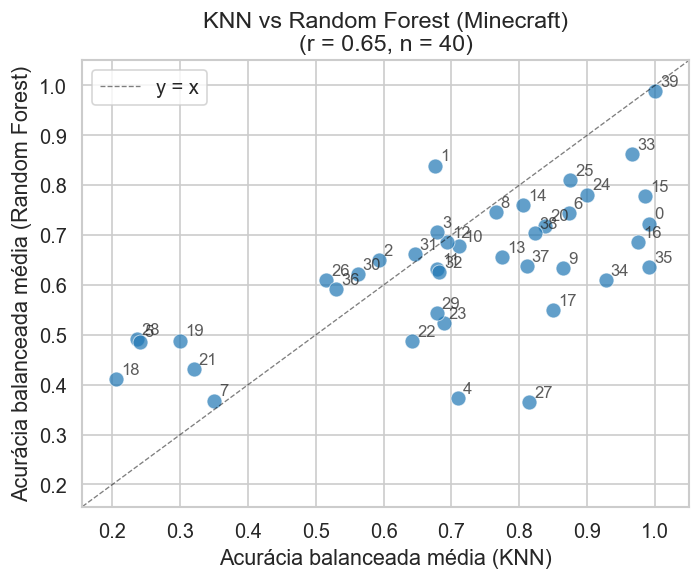

salvo: graficos_pdf\scatter_minecraft_mlp-vs-random-forest.pdf


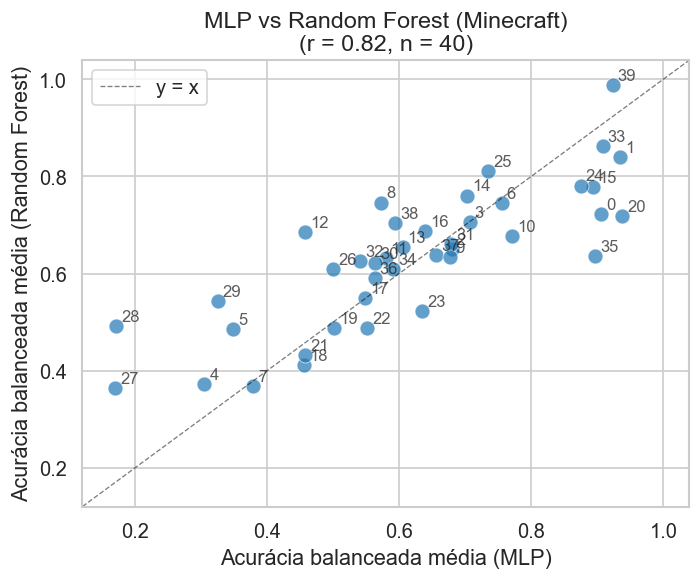

In [7]:
def get_user_scores(classifier, dataset):
    """Retorna Series user_id -> balanced_score_mean na melhor window_size."""
    win = best_window_lookup.get((classifier, dataset))
    if win is None:
        return None
    sub = df_user[
        (df_user['classifier'] == classifier) &
        (df_user['dataset'] == dataset) &
        (df_user['window_size'] == win)
    ]
    return sub.set_index('user_id')['balanced_score_mean']


pairs = list(itertools.combinations(classifiers, 2))

for dataset in datasets:
    for clf_x, clf_y in pairs:
        scores_x = get_user_scores(clf_x, dataset)
        scores_y = get_user_scores(clf_y, dataset)

        if scores_x is None or scores_y is None:
            continue

        common_users = scores_x.index.intersection(scores_y.index)
        if len(common_users) == 0:
            continue

        x = scores_x.loc[common_users].values
        y = scores_y.loc[common_users].values

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(x, y, alpha=0.7, edgecolors='white', linewidth=0.5, s=80)

        lim = (min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05)
        ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5, label='y = x')
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        for uid, xi, yi in zip(common_users, x, y):
            ax.annotate(uid, (xi, yi), fontsize=FS_ANNOT, ha='left',
                        xytext=(3, 3), textcoords='offset points', alpha=0.75)

        corr = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{clf_label(clf_x)} vs {clf_label(clf_y)} ({ds_label(dataset)})\n"
                     f"(r = {corr:.2f}, n = {len(common_users)})")
        ax.set_xlabel(f"Acurácia balanceada média ({clf_label(clf_x)})")
        ax.set_ylabel(f"Acurácia balanceada média ({clf_label(clf_y)})")
        ax.legend()
        fig.tight_layout()

        save_pdf(fig, f"scatter_{dataset}_{clf_x}-vs-{clf_y}")
        plt.show()
        plt.close(fig)


---
## 5.1 Boxplot de balanced_score de usuários por classificador (melhor window_size)

**Uma figura PDF por dataset.**

Registros na melhor window_size por (clf, dataset): 207
salvo: graficos_pdf\boxplot_classificadores_balabit.pdf


C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\2746356227.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


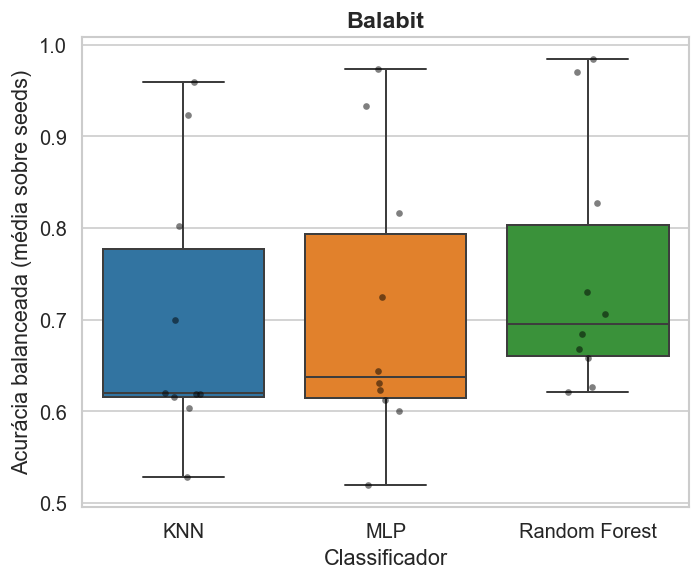

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\2746356227.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_classificadores_bogazici.pdf


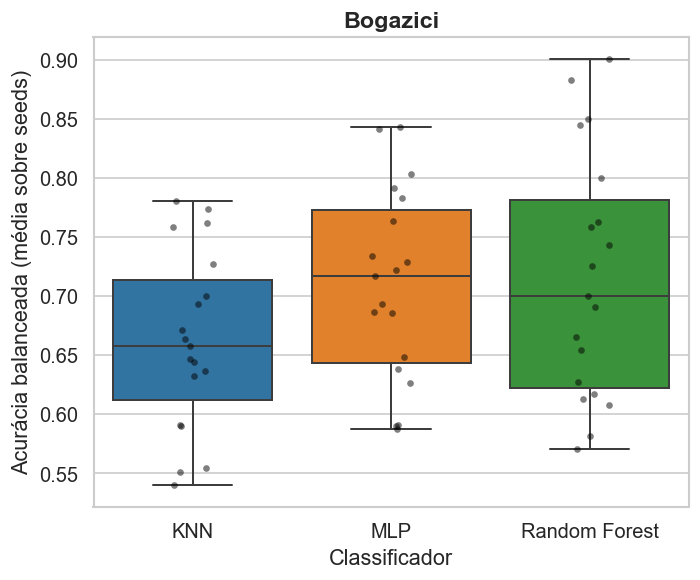

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\2746356227.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_classificadores_minecraft.pdf


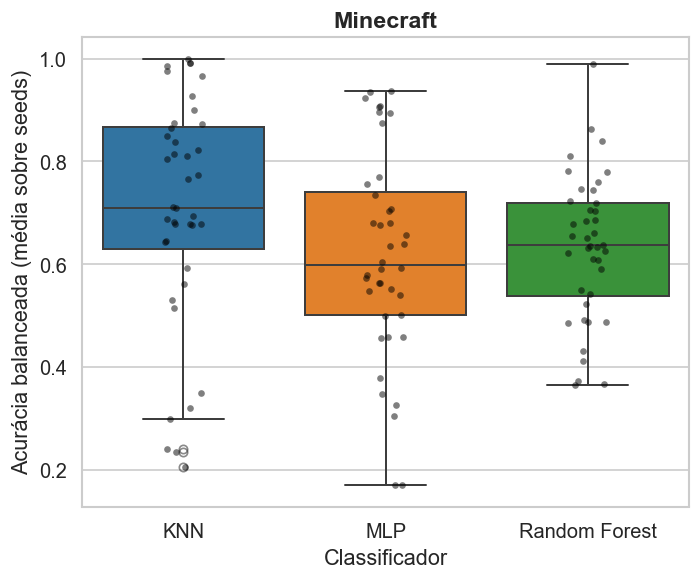

In [20]:
df_best_window = df_user[
    df_user.apply(
        lambda r: best_window_lookup.get((r['classifier'], r['dataset'])) == r['window_size'],
        axis=1,
    )
].copy()

print(f"Registros na melhor window_size por (clf, dataset): {len(df_best_window)}")

for dataset in datasets:
    sub = df_best_window[df_best_window['dataset'] == dataset]
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.boxplot(
        data=sub, x='classifier', y='balanced_score_mean', order=classifiers,
        palette='tab10', linewidth=1.2,
        flierprops=dict(marker='o', markersize=5, alpha=0.6), ax=ax,
    )
    sns.stripplot(
        data=sub, x='classifier', y='balanced_score_mean', order=classifiers,
        color='black', alpha=0.5, size=4, jitter=True, ax=ax,
    )
    rotular_classificadores(ax, classifiers)
    ax.set_xlabel("Classificador")
    ax.set_ylabel("Acurácia balanceada (média sobre seeds)")
    ax.set_title(f"{ds_label(dataset)}", fontweight='bold')
    fig.tight_layout()

    save_pdf(fig, f"boxplot_classificadores_{dataset}")
    plt.show()
    plt.close(fig)


In [9]:
# Estatísticas descritivas
stats = (
    df_best_window
    .groupby(['dataset', 'classifier'])['balanced_score_mean']
    .describe()
    .round(4)
)
display(stats)


count    mean     std     min     25%     50%  \
dataset   classifier                                                     
balabit   knn             10.0  0.6990  0.1464  0.5282  0.6159  0.6196   
          mlp             10.0  0.7077  0.1515  0.5194  0.6149  0.6373   
          random-forest   10.0  0.7476  0.1346  0.6211  0.6608  0.6950   
bogazici  knn             19.0  0.6617  0.0759  0.5399  0.6117  0.6575   
          mlp             19.0  0.7092  0.0818  0.5875  0.6434  0.7171   
          random-forest   19.0  0.7156  0.1041  0.5707  0.6220  0.7004   
minecraft knn             40.0  0.7042  0.2248  0.2057  0.6300  0.7104   
          mlp             40.0  0.6175  0.2032  0.1706  0.5013  0.5994   
          random-forest   40.0  0.6323  0.1419  0.3646  0.5380  0.6366   

                            75%     max  
dataset   classifier                     
balabit   knn            0.7766  0.9590  
          mlp            0.7936  0.9731  
          random-forest  0.8032  0.9847  
bogazici  knn            0.7135  0.7805  
          mlp            0.7732  0.8434  
          random-forest  0.7813  0.9011  
minecraft knn            0.8666  1.0000  
          mlp            0.7400  0.9375  
          random-forest  0.7199  0.9886

### 5.2 Boxplot de balanced_score por window_size (por classificador e dataset)

Usa **todas** as `window_size` disponíveis (todas as configs já consolidadas), mostrando a distribuição de `balanced_score_mean` entre usuários em função do tamanho da janela. **Uma figura PDF por (classificador, dataset).**

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_balabit.pdf


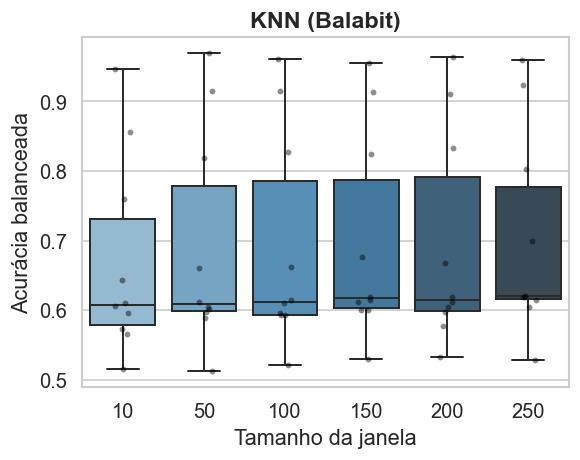

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_bogazici.pdf


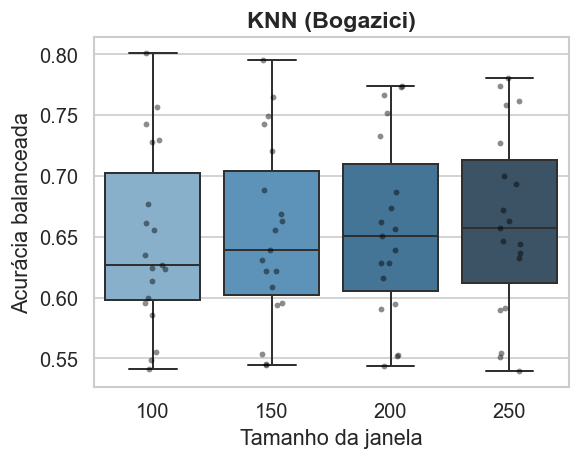

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_knn_minecraft.pdf


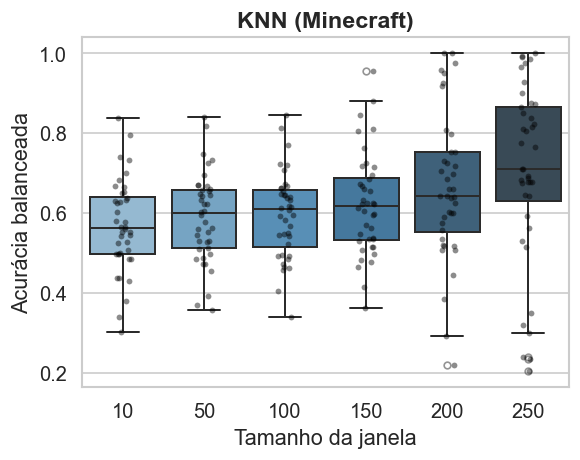

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_balabit.pdf


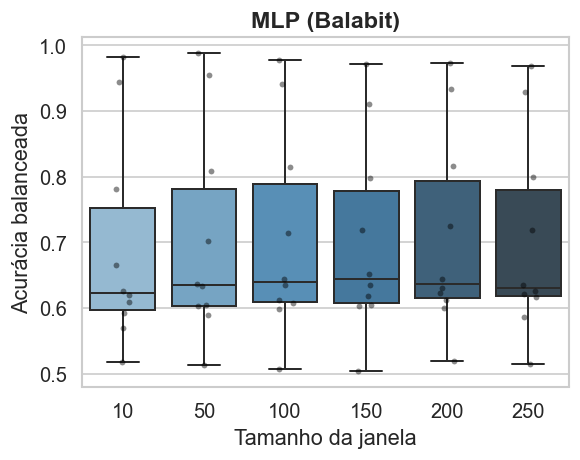

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_bogazici.pdf


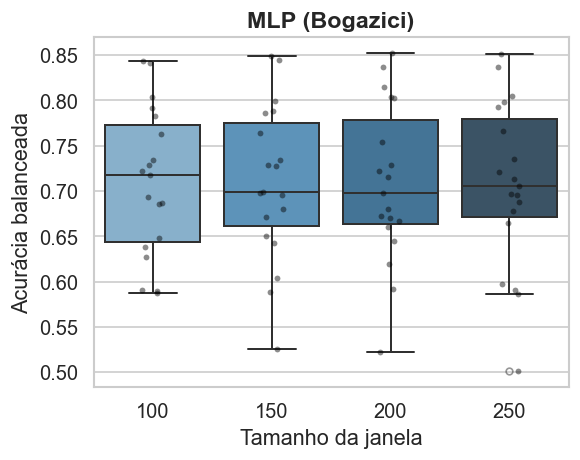

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_mlp_minecraft.pdf


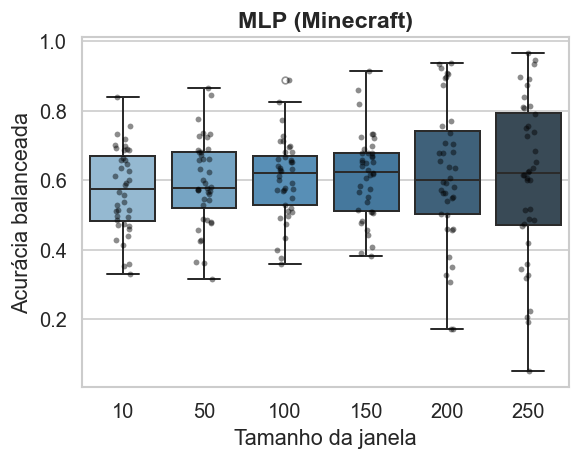

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_balabit.pdf


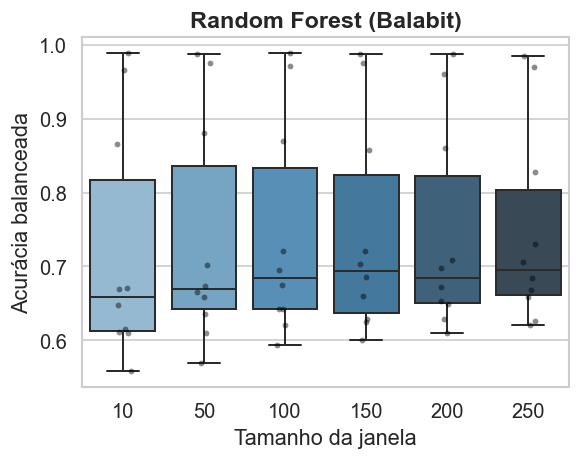

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_bogazici.pdf


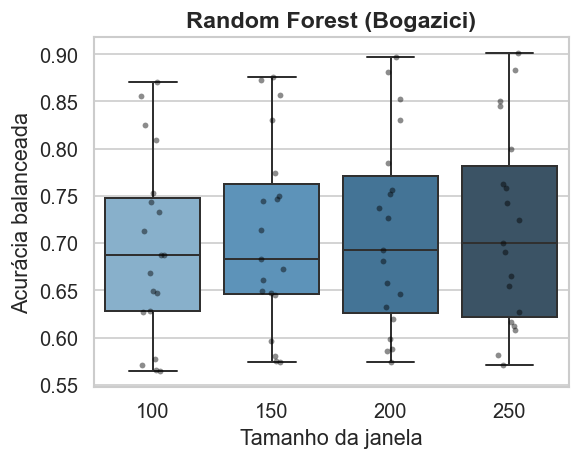

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\755445494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_window_random-forest_minecraft.pdf


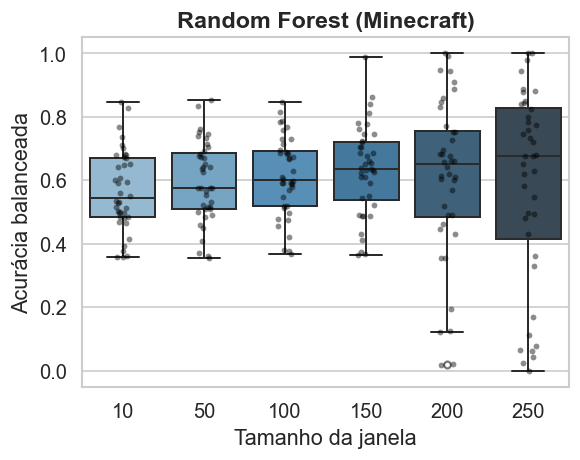

In [21]:
for clf in classifiers:
    for dataset in datasets:
        sub = df_user[(df_user['classifier'] == clf) & (df_user['dataset'] == dataset)]
        if sub.empty:
            continue

        ws_present = sorted(sub['window_size'].unique())

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.boxplot(
            data=sub, x='window_size', y='balanced_score_mean', order=ws_present,
            palette='Blues_d', linewidth=1.2,
            flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax,
        )
        sns.stripplot(
            data=sub, x='window_size', y='balanced_score_mean', order=ws_present,
            color='black', alpha=0.45, size=3.5, jitter=True, ax=ax,
        )
        ax.set_title(titulo(clf, dataset), fontweight='bold')
        ax.set_xlabel("Tamanho da janela")
        ax.set_ylabel("Acurácia balanceada")
        ax.tick_params(axis='x', rotation=0)
        fig.tight_layout()

        save_pdf(fig, f"boxplot_window_{clf}_{dataset}")
        plt.show()
        plt.close(fig)


---
## 6. Boxplot global: todas as window_size (todos os combos)

Variante que usa todas as configs consolidadas, não apenas a melhor `window_size`. Útil para ver o impacto geral da variação de hiperparâmetros. **Uma figura PDF por dataset.**

salvo: graficos_pdf\boxplot_classificadores_todas_windows_balabit.pdf


C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\3905338906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


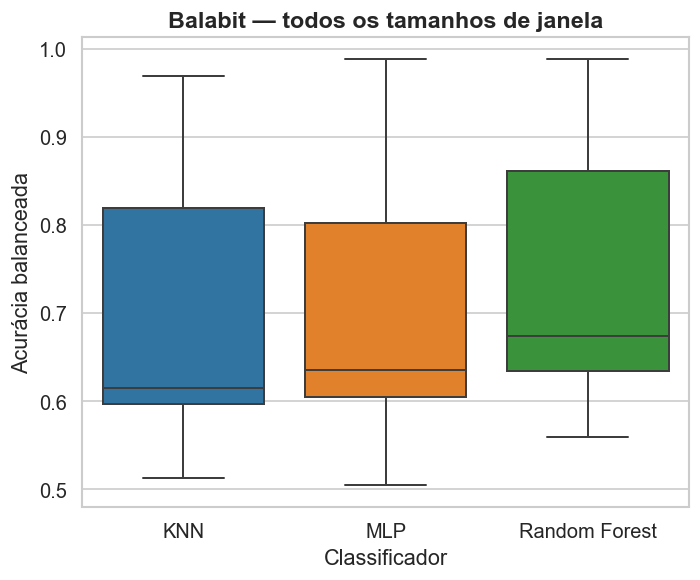

C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\3905338906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


salvo: graficos_pdf\boxplot_classificadores_todas_windows_bogazici.pdf


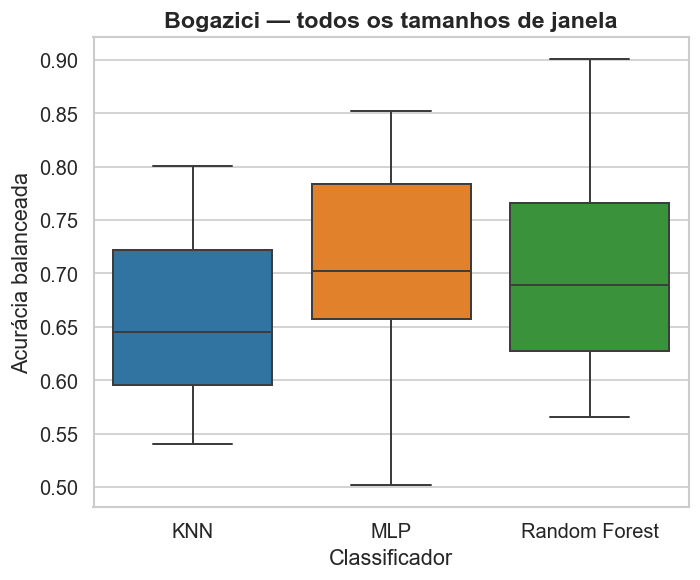

salvo: graficos_pdf\boxplot_classificadores_todas_windows_minecraft.pdf


C:\Users\matmo\AppData\Local\Temp\ipykernel_5228\3905338906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


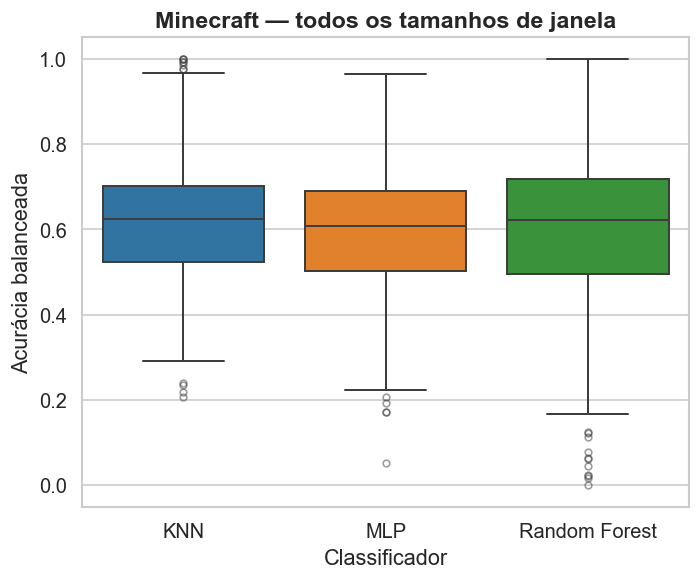

In [22]:
for dataset in datasets:
    sub = df_user[df_user['dataset'] == dataset]
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.boxplot(
        data=sub, x='classifier', y='balanced_score_mean', order=classifiers,
        palette='tab10', linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax,
    )
    rotular_classificadores(ax, classifiers)
    ax.set_xlabel("Classificador")
    ax.set_ylabel("Acurácia balanceada")
    ax.set_title(f"{ds_label(dataset)} — todos os tamanhos de janela", fontweight='bold')
    fig.tight_layout()

    save_pdf(fig, f"boxplot_classificadores_todas_windows_{dataset}")
    plt.show()
    plt.close(fig)


---
## 7. Trajetória de balanced accuracy por usuário x window_size

Cada linha é um usuário (`balanced_score_mean`); as barras de erro mostram `balanced_score_std` (variação entre as 5 seeds) — informação que só existe porque os dados já vêm consolidados. A linha tracejada preta é a média entre usuários. **Uma figura PDF por (dataset, classificador).**

salvo: graficos_pdf\lineplot_usuarios_balabit_knn.pdf


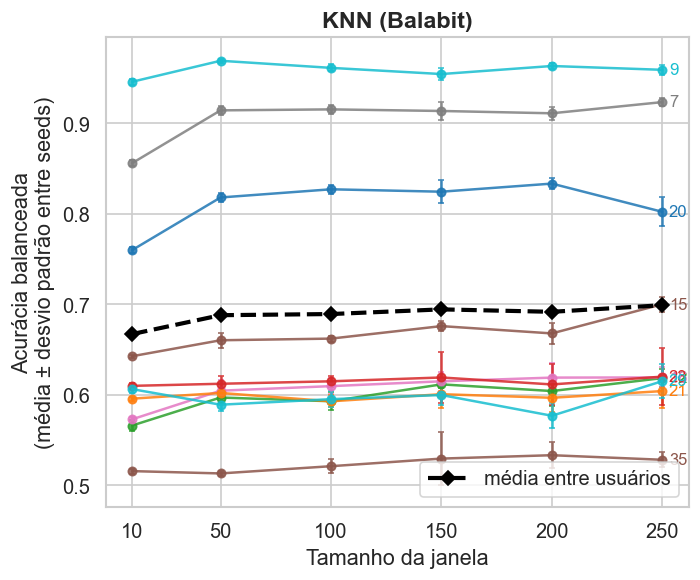

salvo: graficos_pdf\lineplot_usuarios_balabit_mlp.pdf


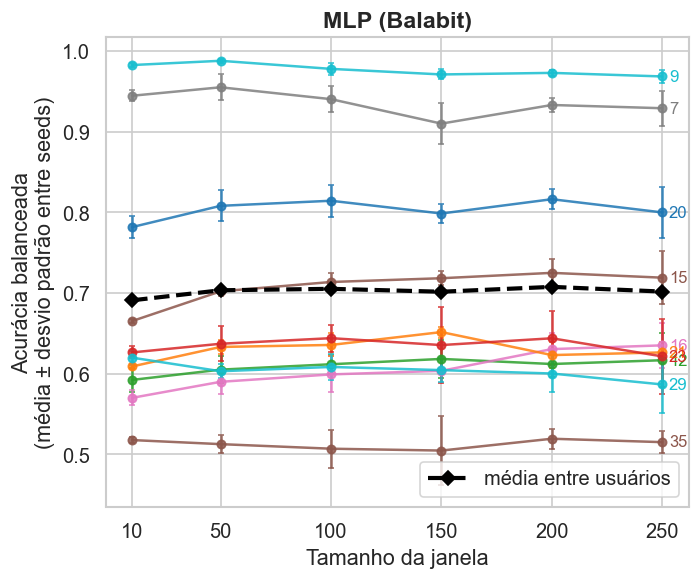

salvo: graficos_pdf\lineplot_usuarios_balabit_random-forest.pdf


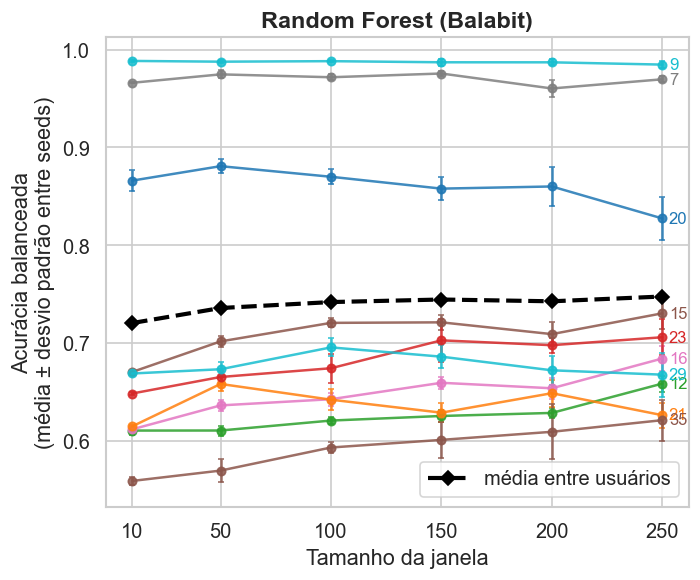

salvo: graficos_pdf\lineplot_usuarios_bogazici_knn.pdf


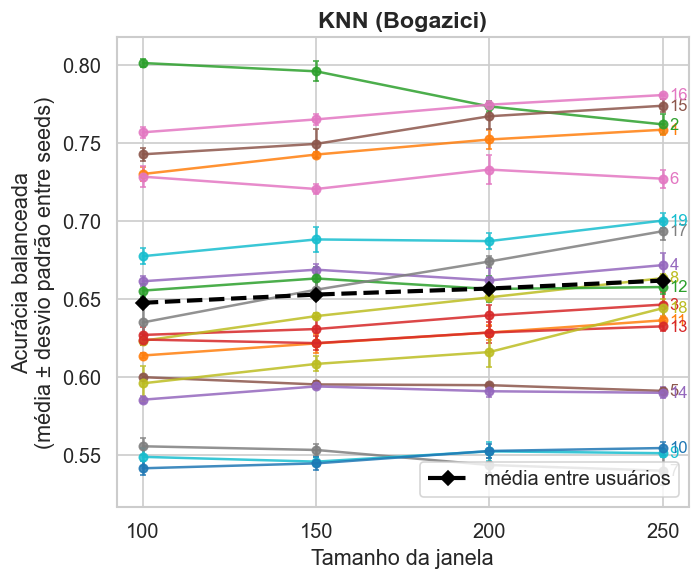

salvo: graficos_pdf\lineplot_usuarios_bogazici_mlp.pdf


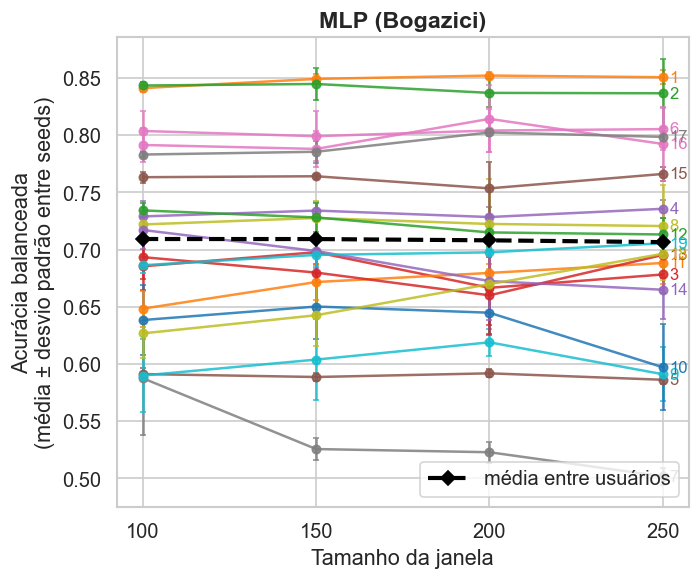

salvo: graficos_pdf\lineplot_usuarios_bogazici_random-forest.pdf


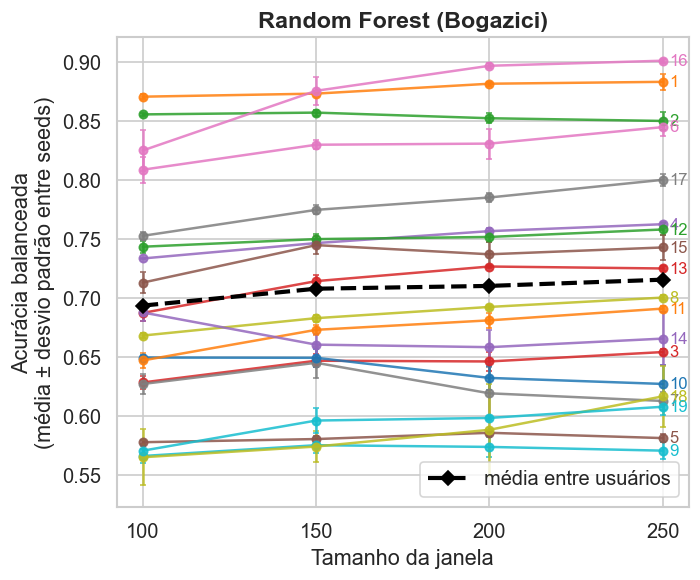

salvo: graficos_pdf\lineplot_usuarios_minecraft_knn.pdf


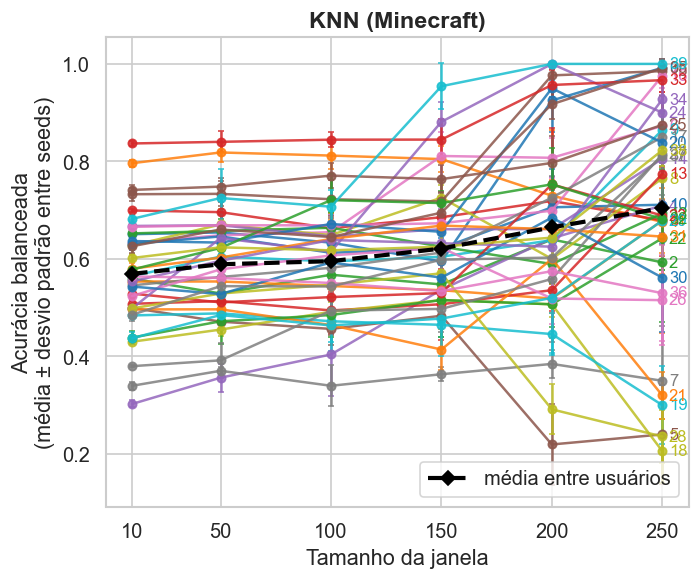

salvo: graficos_pdf\lineplot_usuarios_minecraft_mlp.pdf


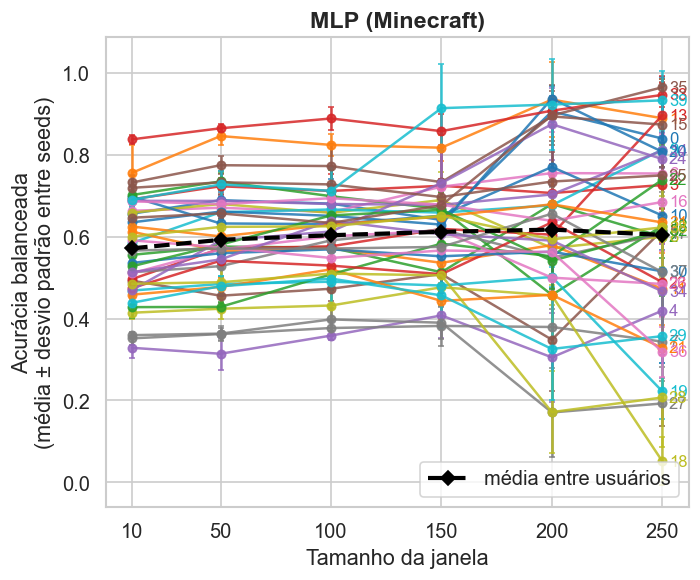

salvo: graficos_pdf\lineplot_usuarios_minecraft_random-forest.pdf


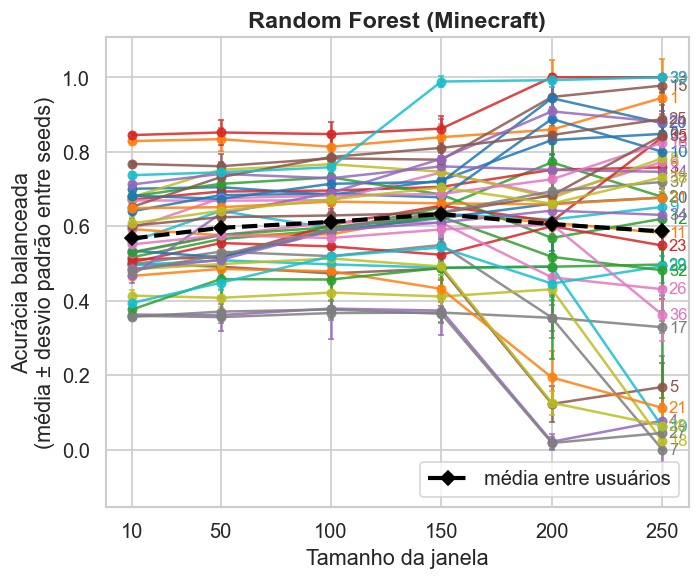

In [12]:
palette_users = sns.color_palette('tab10', n_colors=df_user['user_id'].nunique())
user_ids_sorted = sorted(df_user['user_id'].unique())
user_colors = {uid: palette_users[i % len(palette_users)] for i, uid in enumerate(user_ids_sorted)}

for dataset in datasets:
    for clf in classifiers:
        sub = df_user[(df_user['dataset'] == dataset) & (df_user['classifier'] == clf)]
        if sub.empty:
            continue

        window_sizes = sorted(sub['window_size'].unique())

        fig, ax = plt.subplots(figsize=(6, 5))
        for uid, grp in sub.groupby('user_id'):
            grp_sorted = grp.sort_values('window_size')
            ax.errorbar(
                grp_sorted['window_size'], grp_sorted['balanced_score_mean'],
                yerr=grp_sorted['balanced_score_std'],
                marker='o', linewidth=1.5, markersize=5, capsize=2,
                color=user_colors[uid], alpha=0.85,
            )
            last = grp_sorted.iloc[-1]
            ax.annotate(
                uid, (last['window_size'], last['balanced_score_mean']),
                fontsize=FS_ANNOT, xytext=(4, 0), textcoords='offset points',
                color=user_colors[uid], va='center',
            )

        mean_per_ws = sub.groupby('window_size')['balanced_score_mean'].mean()
        ax.plot(
            mean_per_ws.index, mean_per_ws.values,
            color='black', linewidth=2.5, linestyle='--', marker='D', markersize=6,
            label='média entre usuários', zorder=5,
        )

        ax.set_xticks(window_sizes)
        ax.set_title(titulo(clf, dataset), fontweight='bold')
        ax.set_xlabel("Tamanho da janela")
        ax.set_ylabel("Acurácia balanceada\n(média ± desvio padrão entre seeds)")
        ax.legend(loc='lower right')
        fig.tight_layout()

        save_pdf(fig, f"lineplot_usuarios_{dataset}_{clf}")
        plt.show()
        plt.close(fig)


---
## 8. Heatmap: balanced accuracy por usuário x window_size

**Uma figura PDF por (dataset, classificador).**

salvo: graficos_pdf\heatmap_balabit_knn.pdf


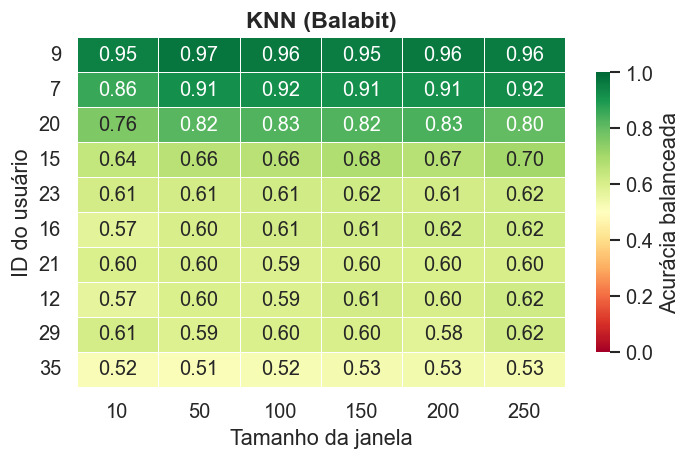

salvo: graficos_pdf\heatmap_balabit_mlp.pdf


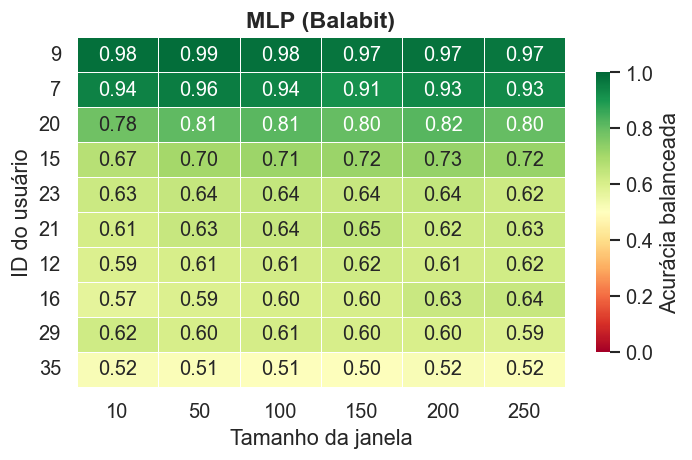

salvo: graficos_pdf\heatmap_balabit_random-forest.pdf


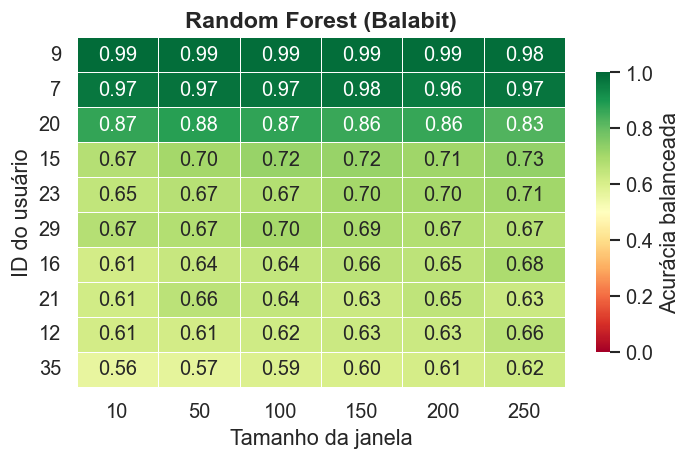

salvo: graficos_pdf\heatmap_bogazici_knn.pdf


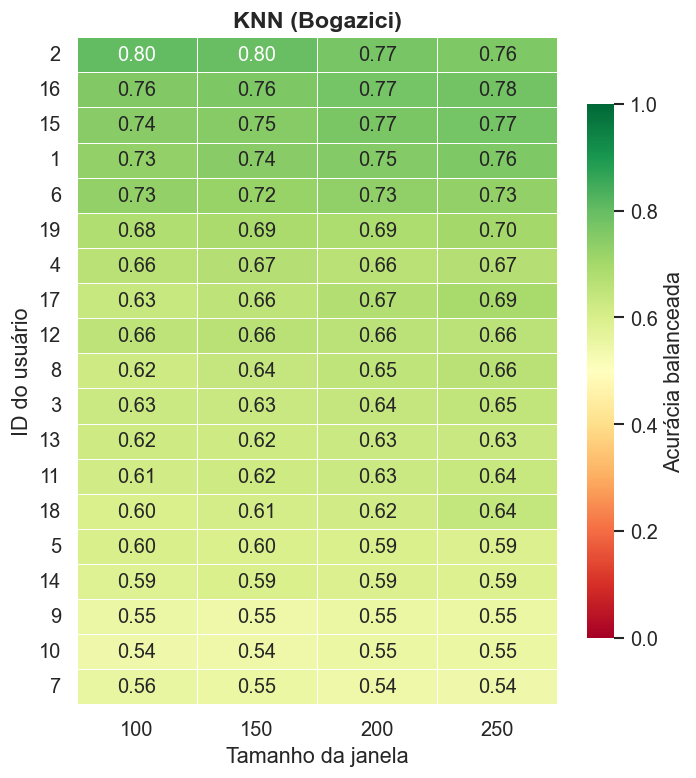

salvo: graficos_pdf\heatmap_bogazici_mlp.pdf


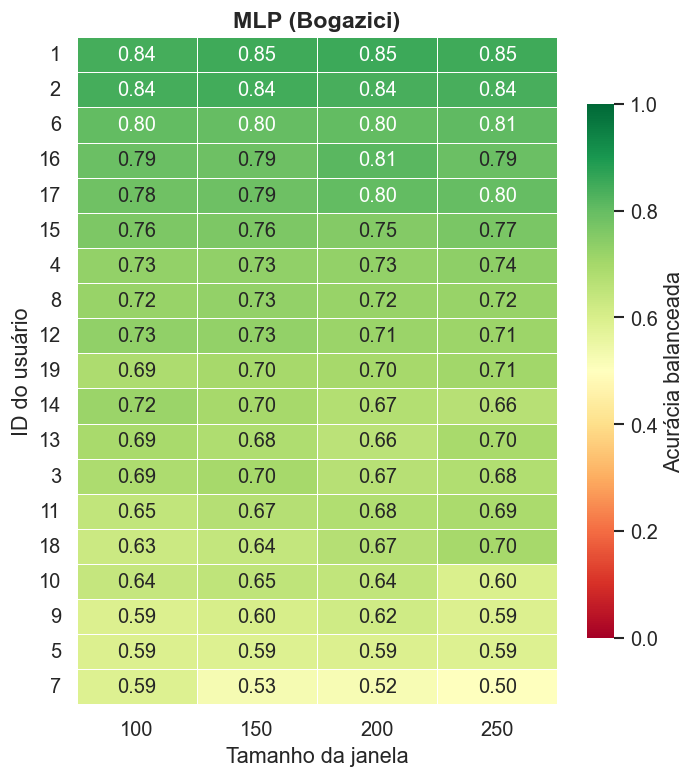

salvo: graficos_pdf\heatmap_bogazici_random-forest.pdf


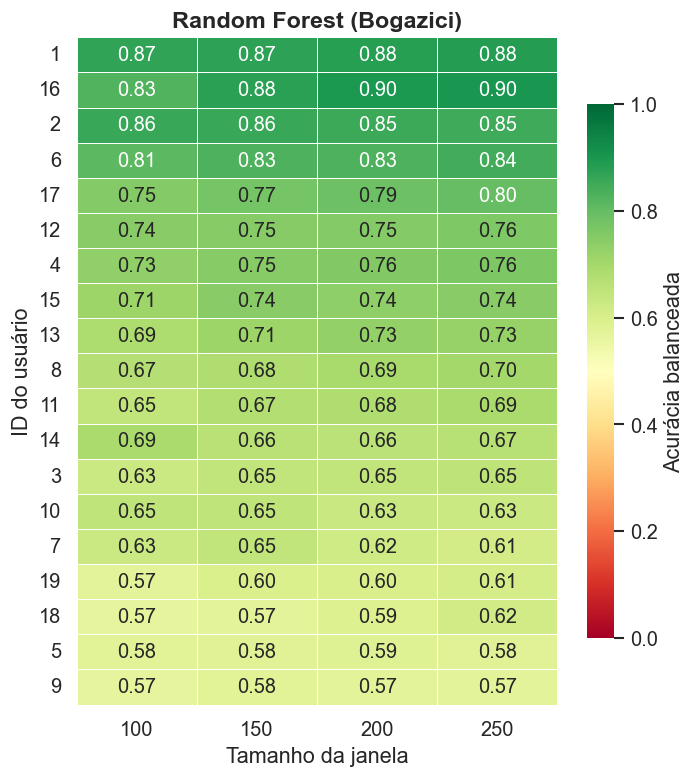

salvo: graficos_pdf\heatmap_minecraft_knn.pdf


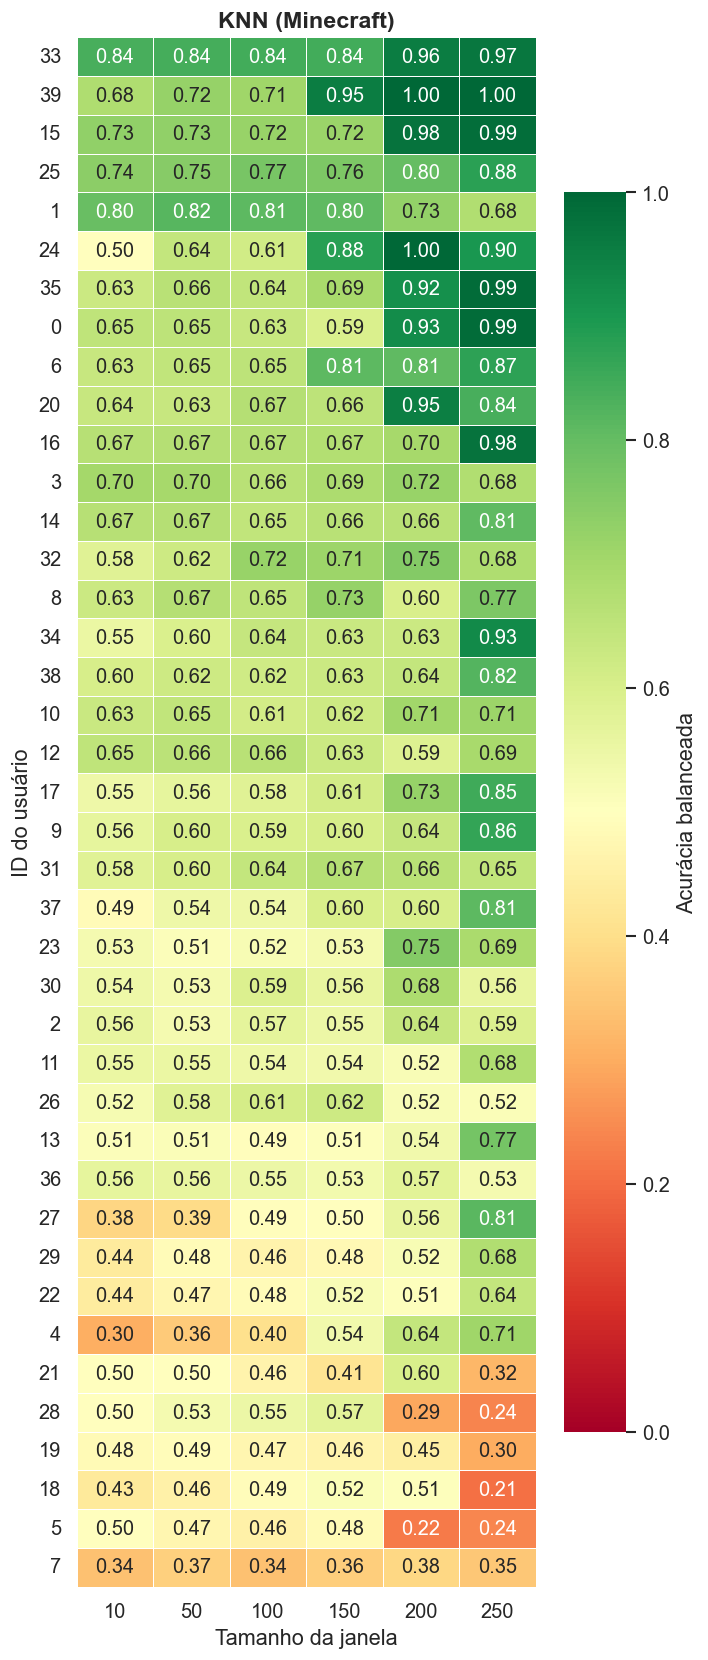

salvo: graficos_pdf\heatmap_minecraft_mlp.pdf


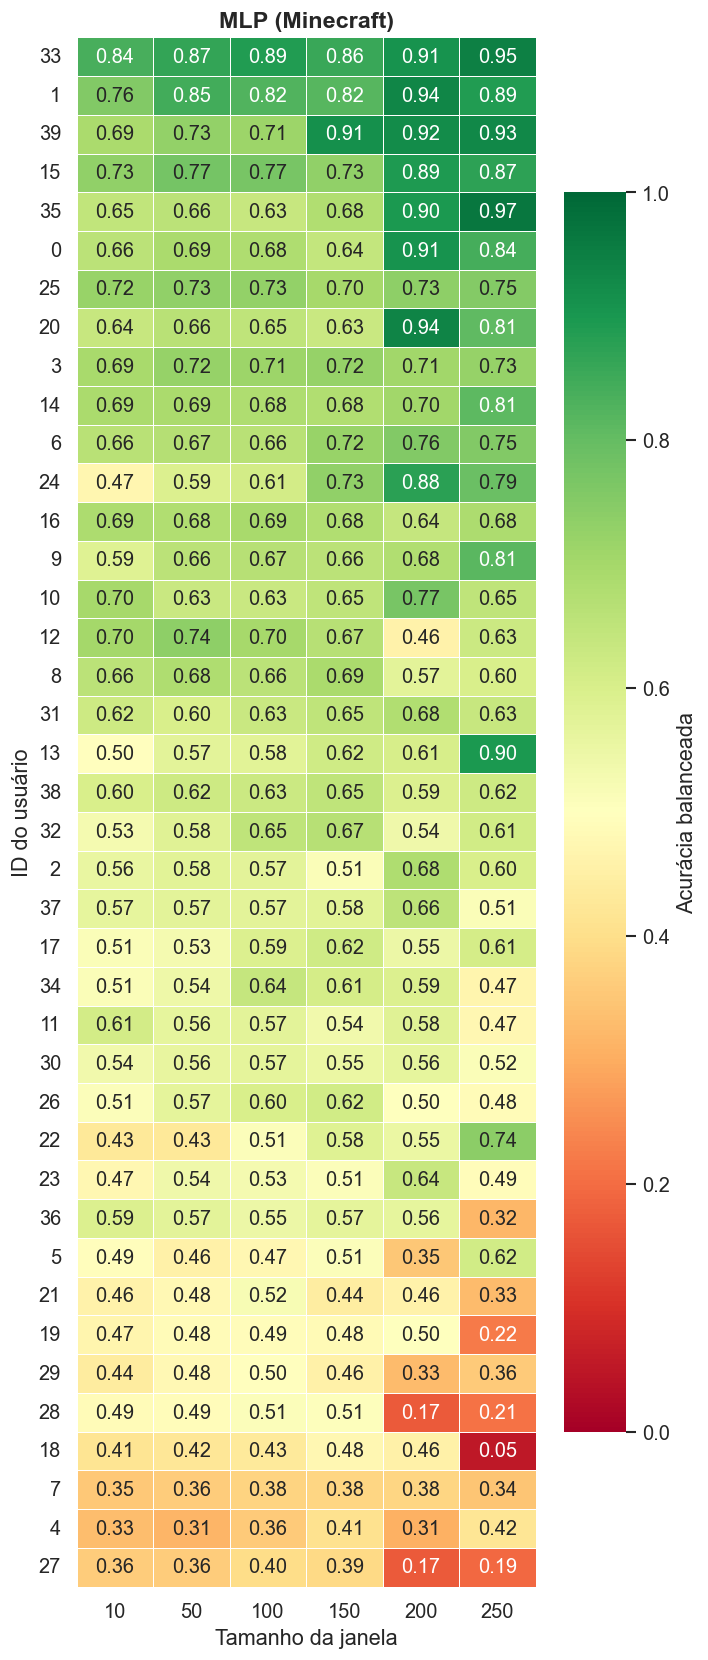

salvo: graficos_pdf\heatmap_minecraft_random-forest.pdf


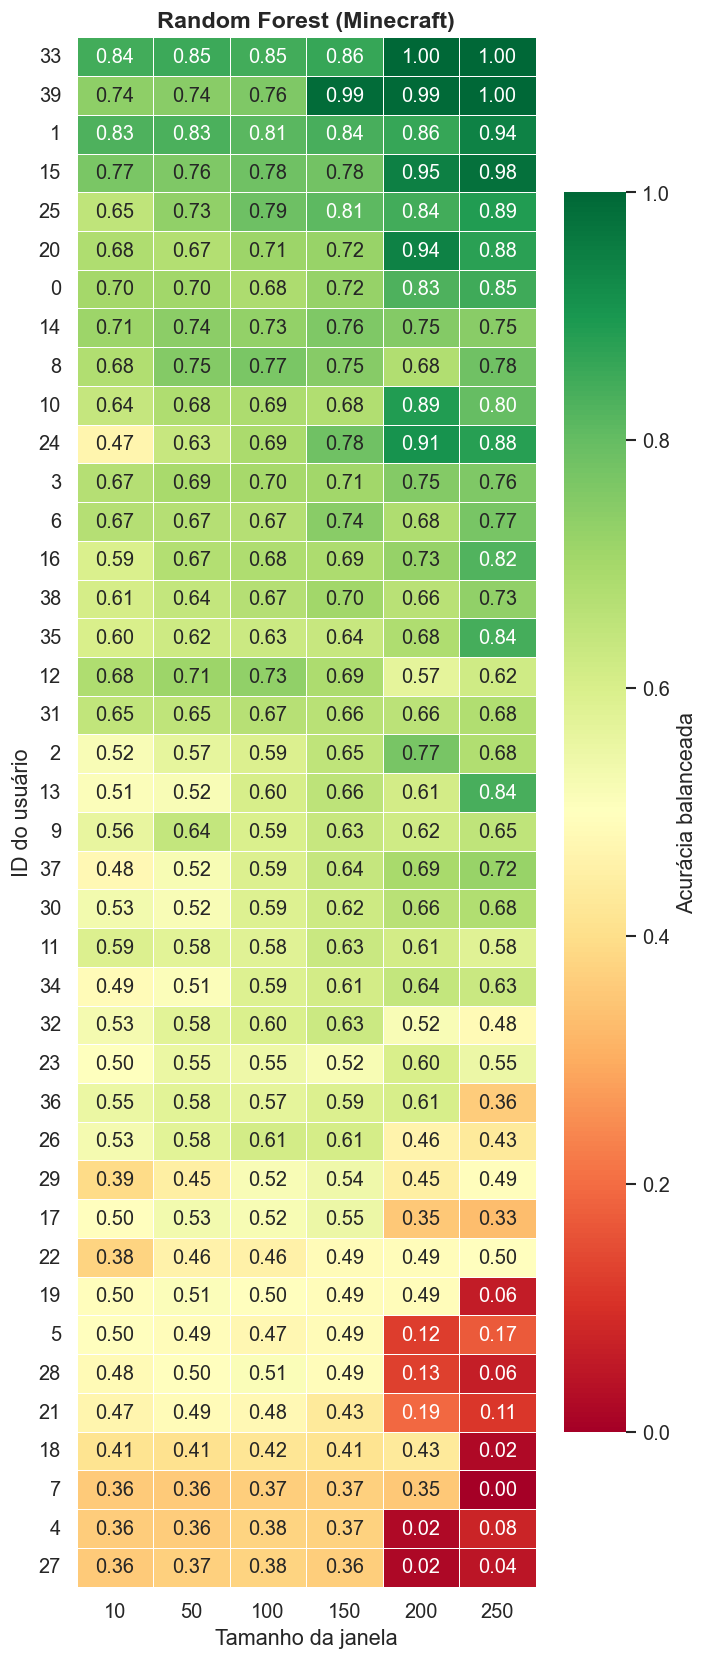

In [23]:
for dataset in datasets:
    for clf in classifiers:
        sub = df_user[(df_user['dataset'] == dataset) & (df_user['classifier'] == clf)]
        if sub.empty:
            continue

        pivot = (
            sub.pivot_table(index='user_id', columns='window_size', values='balanced_score_mean')
            .sort_index()
        )
        pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

        fig, ax = plt.subplots(figsize=(6, max(4, 0.35 * len(pivot))))
        sns.heatmap(
            pivot, ax=ax, cmap='RdYlGn', vmin=0.0, vmax=1.0,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Acurácia balanceada'},
        )
        ax.set_title(titulo(clf, dataset), fontweight='bold')
        ax.set_xlabel("Tamanho da janela")
        ax.set_ylabel("ID do usuário")
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)
        fig.tight_layout()

        save_pdf(fig, f"heatmap_{dataset}_{clf}")
        plt.show()
        plt.close(fig)


---
## 9. Comparação estatística entre classificadores (Friedman + Nemenyi)

Aqui comparamos os 3 classificadores diretamente, usando o `balanced_score_mean` de cada usuário (já com média sobre as 5 seeds) na melhor `window_size` de cada classificador. A comparação é restrita à **interseção de usuários testados pelos 3 classificadores em cada dataset** — necessário para que a comparação seja pareada e justa (um classificador não pode "ganhar de graça" em usuários que os outros nunca viram).

Como cada usuário é medido pelos 3 classificadores (dados pareados, não independentes) e balanced accuracy não segue distribuição normal, usamos:

1. **Teste de Friedman** por dataset (H0: os 3 classificadores têm desempenho igual), usando os usuários como blocos/réplicas;
2. Se significativo (p < 0,05), **pós-hoc de Nemenyi** para identificar quais pares diferem entre si;
3. Um **diagrama de diferença crítica** por dataset, que mostra o ranking médio de cada classificador e conecta com uma barra os pares que não diferem estatisticamente.

Com apenas 3 datasets, **não** é feito um Friedman *entre* datasets — não há poder estatístico suficiente com tão poucos "problemas" para isso (ver Demšar, 2006). O ranking médio entre datasets, na seção 9.1, é puramente descritivo.

In [14]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp


def build_wide_table(dataset):
    """DataFrame (linhas=user_id, colunas=classificador) com o
    balanced_score_mean de cada classificador na sua melhor window_size,
    restrito aos usuários testados pelos 3 classificadores nesse dataset."""
    per_clf = {}
    for clf in classifiers:
        scores = get_user_scores(clf, dataset)
        if scores is not None:
            per_clf[clf] = scores

    wide = pd.DataFrame(per_clf)
    wide = wide.dropna()  # mantém só usuários presentes em todos os classificadores
    return wide


friedman_results = []
wide_tables = {}

for dataset in datasets:
    wide = build_wide_table(dataset)
    if wide.shape[1] < 3 or wide.shape[0] < 3:
        print(f"{dataset}: dados insuficientes para o teste "
              f"(n_usuarios_comuns={wide.shape[0]}, n_classificadores={wide.shape[1]})")
        continue

    wide_tables[dataset] = wide
    stat, pvalue = friedmanchisquare(*[wide[c] for c in classifiers])
    friedman_results.append({
        'dataset': dataset,
        'n_usuarios_comuns': wide.shape[0],
        'friedman_stat': stat,
        'p_value': pvalue,
        'significativo (p<0.05)': pvalue < 0.05,
    })

df_friedman = pd.DataFrame(friedman_results)
display(df_friedman)


,dataset,n_usuarios_comuns,friedman_stat,p_value,significativo (p<0.05)
0,balabit,10,15.800000,0.000371,True
1,bogazici,19,11.368421,0.003399,True
2,minecraft,40,7.350000,0.025349,True


### 9.1 Pós-hoc de Nemenyi e diagrama de diferença crítica

Para cada dataset com resultado significativo no teste de Friedman. **Uma figura PDF por dataset.**


=== balabit (n_usuarios_comuns=10) ===
Ranking médio (1 = melhor):
random-forest    1.0
mlp              2.3
knn              2.7

Matriz de p-valores (pós-hoc de Nemenyi):


,knn,mlp,random-forest
knn,1.0000,0.6438,0.0004
mlp,0.6438,1.0000,0.0102
random-forest,0.0004,0.0102,1.0000


salvo: graficos_pdf\cd_diagram_balabit.pdf


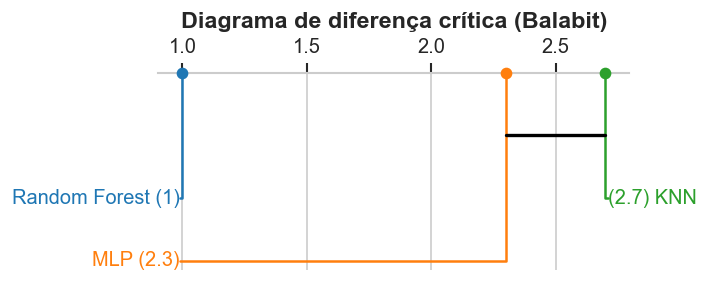


=== bogazici (n_usuarios_comuns=19) ===
Ranking médio (1 = melhor):
mlp              1.68
random-forest    1.68
knn              2.63

Matriz de p-valores (pós-hoc de Nemenyi):


,knn,mlp,random-forest
knn,1.0000,0.0098,0.0098
mlp,0.0098,1.0000,1.0000
random-forest,0.0098,1.0000,1.0000


salvo: graficos_pdf\cd_diagram_bogazici.pdf


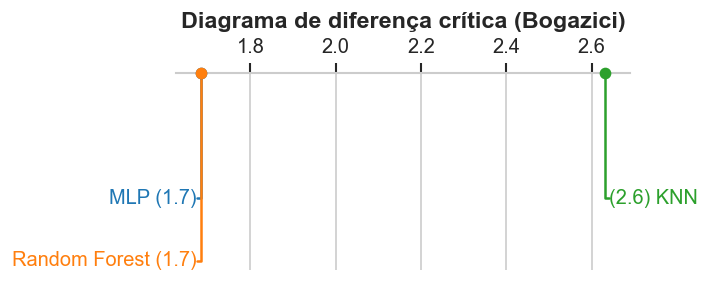


=== minecraft (n_usuarios_comuns=40) ===
Ranking médio (1 = melhor):
knn              1.65
mlp              2.17
random-forest    2.17

Matriz de p-valores (pós-hoc de Nemenyi):


,knn,mlp,random-forest
knn,1.0000,0.0495,0.0495
mlp,0.0495,1.0000,1.0000
random-forest,0.0495,1.0000,1.0000


salvo: graficos_pdf\cd_diagram_minecraft.pdf


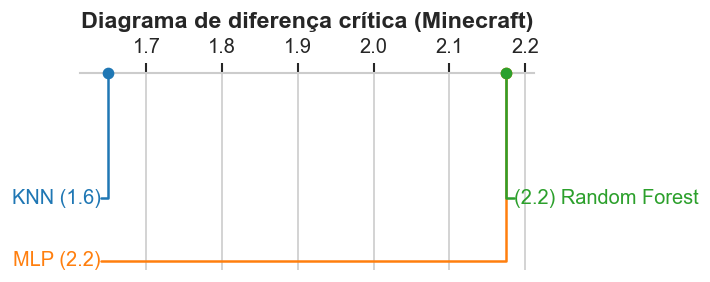

In [15]:
average_ranks_by_dataset = {}

for dataset, wide in wide_tables.items():
    sig = df_friedman.loc[df_friedman['dataset'] == dataset, 'significativo (p<0.05)'].iloc[0]

    # rank 1 = melhor (maior balanced_score) por usuário
    ranks = wide.rank(axis=1, ascending=False)
    avg_rank = ranks.mean()
    average_ranks_by_dataset[dataset] = avg_rank

    print(f"\n=== {dataset} (n_usuarios_comuns={wide.shape[0]}) ===")
    print("Ranking médio (1 = melhor):")
    print(avg_rank.sort_values().round(2).to_string())

    if not sig:
        print("Friedman não significativo — sem diferença estatística detectada "
              "entre os classificadores; pulando pós-hoc e diagrama.")
        continue

    sig_matrix = sp.posthoc_nemenyi_friedman(wide.values)
    sig_matrix.index = wide.columns
    sig_matrix.columns = wide.columns
    print("\nMatriz de p-valores (pós-hoc de Nemenyi):")
    display(sig_matrix.round(4))

    fig, ax = plt.subplots(figsize=(6, 2.5))
    sp.critical_difference_diagram(
        avg_rank.rename(CLF_LABELS),
        sig_matrix.rename(index=CLF_LABELS, columns=CLF_LABELS),
        ax=ax, label_props={'fontsize': FS_CD},
    )
    ax.set_title(f"Diagrama de diferença crítica ({ds_label(dataset)})", fontweight='bold')
    fig.tight_layout()

    save_pdf(fig, f"cd_diagram_{dataset}")
    plt.show()
    plt.close(fig)


### 9.2 Ranking médio entre datasets (resumo descritivo)

**Atenção:** esta agregação entre os 3 datasets é puramente descritiva — não corresponde a um teste estatístico formal (não há poder suficiente com apenas 3 "problemas" para isso, ver Demšar 2006). Os testes de Friedman/Nemenyi por dataset acima são a evidência estatística válida; esta tabela só dá uma visão geral de qual classificador tende a se sair melhor com mais consistência, cruzada com a estabilidade entre seeds (`mean_balanced_score_cv`, já calculada pelo `consolidar_resultados.py`). **Uma figura PDF.**

,balabit,bogazici,minecraft,rank_medio_entre_datasets,cv_medio_pct
random-forest,1.0,1.684,2.175,1.620,0.777
mlp,2.3,1.684,2.175,2.053,1.103
knn,2.7,2.632,1.650,2.327,0.679


salvo: graficos_pdf\ranking_medio_classificadores.pdf


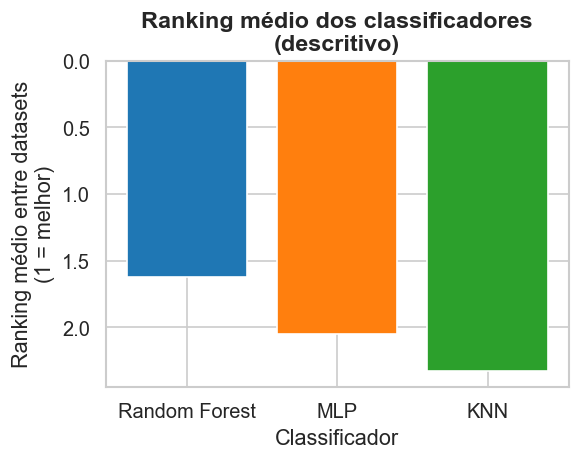

In [16]:
if average_ranks_by_dataset:
    rank_summary = pd.DataFrame(average_ranks_by_dataset)
    rank_summary['rank_medio_entre_datasets'] = rank_summary.mean(axis=1)
    rank_summary = rank_summary.sort_values('rank_medio_entre_datasets')

    # CV médio (estabilidade entre seeds) na melhor window_size de cada (classificador, dataset)
    cv_lookup = best_window_per_clf_ds.groupby('classifier')['mean_balanced_score_cv'].mean() * 100
    rank_summary['cv_medio_pct'] = cv_lookup

    display(rank_summary.round(3))

    fig, ax = plt.subplots(figsize=(5, 4))
    order = rank_summary.index.tolist()
    ax.bar([clf_label(c) for c in order], rank_summary['rank_medio_entre_datasets'], color=sns.color_palette('tab10', len(order)))
    ax.set_ylabel("Ranking médio entre datasets\n(1 = melhor)")
    ax.set_xlabel("Classificador")
    ax.invert_yaxis()
    ax.set_title("Ranking médio dos classificadores\n(descritivo)", fontweight='bold')
    fig.tight_layout()

    save_pdf(fig, "ranking_medio_classificadores")
    plt.show()
    plt.close(fig)
else:
    print("Nenhum dataset teve dados suficientes para calcular o ranking.")


---
## 10. Efeito da window_size (Friedman + Nemenyi por classificador/dataset)

Mesma lógica da seção 9, mas agora comparando as `window_size` disponíveis **dentro de cada (dataset, classificador)**, em vez de comparar classificadores. Como o efeito da `window_size` pode depender do classificador e do dataset (já vimos isso nas seções 5.2 e 7 — RF/MLP sobem e depois caem no minecraft, KNN sobe monotonicamente), o teste é feito **separadamente para cada uma das 9 combinações**, não agregado.

1. **Teste de Friedman** por (dataset, classificador) — H0: a `window_size` não afeta o `balanced_score`, usando os usuários como blocos/réplicas (cada usuário testado em todas as `window_size` daquele dataset/classificador).
2. Se significativo (p < 0,05), **pós-hoc de Nemenyi** para identificar quais `window_size` diferem entre si — resumido como "melhor window (menor ranking médio) + quais empatam com ela + quais são significativamente piores".
3. Um **diagrama de diferença crítica** só para os casos significativos, que compactam melhor a informação do que uma tabela de todos os pares possíveis (até 15 pares por combinação com 6 janelas).

Esta seção **complementa**, não substitui, as análises descritivas das seções 5.2, 7 e 8 — os gráficos mostram a *forma* da relação (inclusive padrões não-monotônicos), o teste aqui mostra quais diferenças observadas são estatisticamente sustentáveis.

In [17]:
friedman_window_results = []
wide_tables_window = {}

for (dataset, clf), g in df_user.groupby(['dataset', 'classifier']):
    wide = g.pivot_table(index='user_id', columns='window_size', values='balanced_score_mean')
    wide = wide.dropna()  # mantém só usuários presentes em todas as window_size
    windows = sorted(wide.columns.tolist())

    if len(windows) < 3 or wide.shape[0] < 3:
        print(f"{dataset}/{clf}: dados insuficientes para o teste "
              f"(n_usuarios={wide.shape[0]}, n_windows={len(windows)})")
        continue

    wide_tables_window[(dataset, clf)] = wide
    stat, pvalue = friedmanchisquare(*[wide[w] for w in windows])
    friedman_window_results.append({
        'dataset': dataset,
        'classifier': clf,
        'n_usuarios': wide.shape[0],
        'n_windows': len(windows),
        'friedman_stat': stat,
        'p_value': pvalue,
        'significativo (p<0.05)': pvalue < 0.05,
    })

df_friedman_window = pd.DataFrame(friedman_window_results)
display(df_friedman_window.round(5))


,dataset,classifier,n_usuarios,n_windows,friedman_stat,p_value,significativo (p<0.05)
0,balabit,knn,10,6,19.48571,0.00156,True
1,balabit,mlp,10,6,4.11429,0.53308,False
2,balabit,random-forest,10,6,8.80000,0.11731,False
3,bogazici,knn,19,4,14.68421,0.00211,True
4,bogazici,mlp,19,4,1.35789,0.71543,False
5,bogazici,random-forest,19,4,17.21053,0.00064,True
6,minecraft,knn,40,6,43.59442,0.00000,True
7,minecraft,mlp,40,6,16.75714,0.00498,True
8,minecraft,random-forest,40,6,38.14510,0.00000,True


### 10.1 Pós-hoc de Nemenyi e diagrama de diferença crítica

Para cada (dataset, classificador) com resultado significativo no teste de Friedman. **Uma figura PDF por combinação.**


=== balabit / knn (n_usuarios=10) ===
Ranking médio por window_size (1 = melhor):
window_size
250    1.9
150    2.9
200    3.2
100    3.7
50     3.9
10     5.4
salvo: graficos_pdf\cd_diagram_window_balabit_knn.pdf


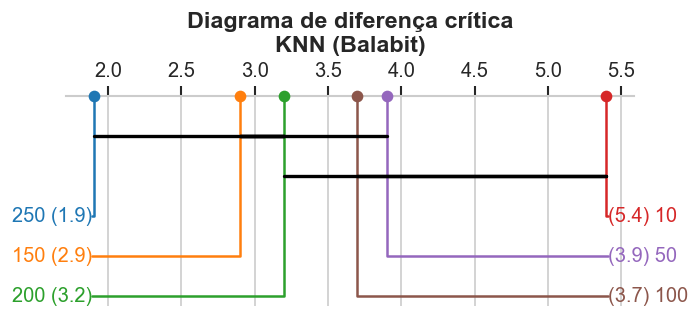


=== balabit / mlp (n_usuarios=10) ===
Ranking médio por window_size (1 = melhor):
window_size
200    2.8
100    3.0
50     3.4
150    3.7
250    3.9
10     4.2
Friedman não significativo — window_size não parece afetar o desempenho de forma estatisticamente detectável aqui; pulando pós-hoc e diagrama.

=== balabit / random-forest (n_usuarios=10) ===
Ranking médio por window_size (1 = melhor):
window_size
150    2.8
100    3.0
250    3.2
50     3.5
200    3.5
10     5.0
Friedman não significativo — window_size não parece afetar o desempenho de forma estatisticamente detectável aqui; pulando pós-hoc e diagrama.

=== bogazici / knn (n_usuarios=19) ===
Ranking médio por window_size (1 = melhor):
window_size
250    1.79
200    2.21
150    2.68
100    3.32
salvo: graficos_pdf\cd_diagram_window_bogazici_knn.pdf


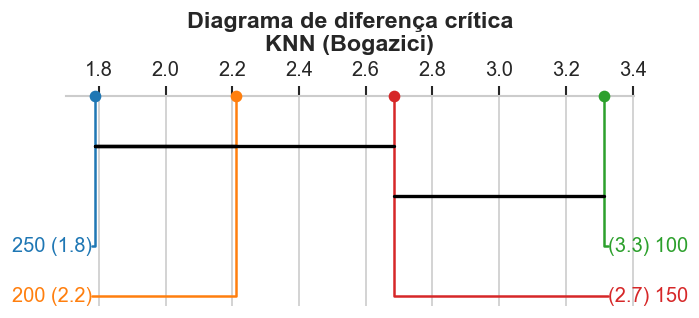


=== bogazici / mlp (n_usuarios=19) ===
Ranking médio por window_size (1 = melhor):
window_size
150    2.37
200    2.37
250    2.47
100    2.79
Friedman não significativo — window_size não parece afetar o desempenho de forma estatisticamente detectável aqui; pulando pós-hoc e diagrama.

=== bogazici / random-forest (n_usuarios=19) ===
Ranking médio por window_size (1 = melhor):
window_size
250    1.79
200    2.26
150    2.47
100    3.47
salvo: graficos_pdf\cd_diagram_window_bogazici_random-forest.pdf


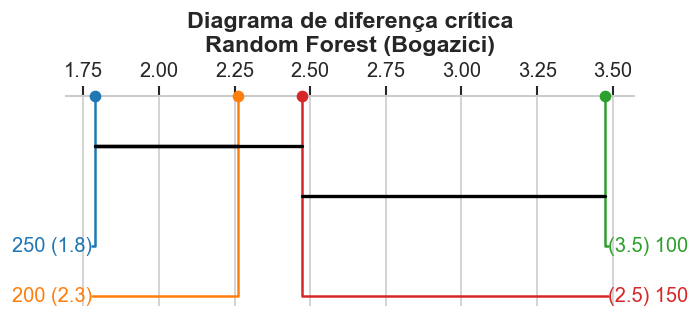


=== minecraft / knn (n_usuarios=40) ===
Ranking médio por window_size (1 = melhor):
window_size
250    2.45
200    2.59
150    3.41
50     3.80
100    4.03
10     4.72
salvo: graficos_pdf\cd_diagram_window_minecraft_knn.pdf


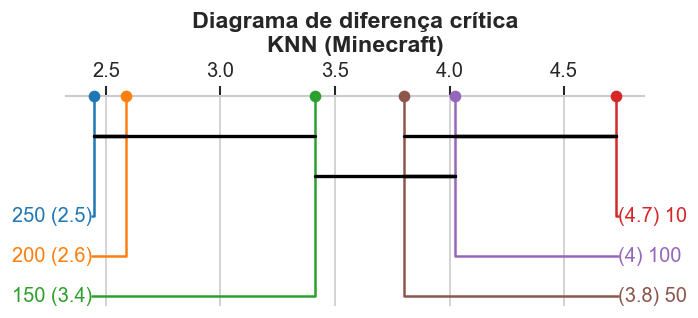


=== minecraft / mlp (n_usuarios=40) ===
Ranking médio por window_size (1 = melhor):
window_size
200    3.05
150    3.25
100    3.25
250    3.32
50     3.58
10     4.55
salvo: graficos_pdf\cd_diagram_window_minecraft_mlp.pdf


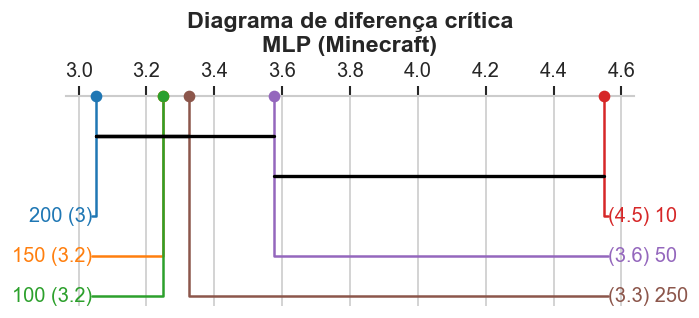


=== minecraft / random-forest (n_usuarios=40) ===
Ranking médio por window_size (1 = melhor):
window_size
150    2.80
250    2.89
200    3.06
100    3.35
50     3.98
10     4.92
salvo: graficos_pdf\cd_diagram_window_minecraft_random-forest.pdf


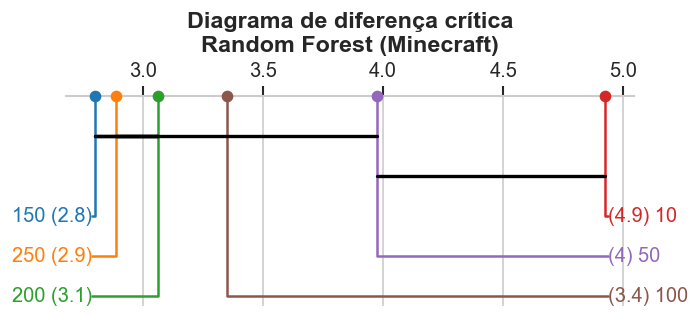

In [18]:
window_summary_rows = []

for (dataset, clf), wide in wide_tables_window.items():
    mask = (
        (df_friedman_window['dataset'] == dataset) &
        (df_friedman_window['classifier'] == clf)
    )
    sig = df_friedman_window.loc[mask, 'significativo (p<0.05)'].iloc[0]

    # rank 1 = melhor (maior balanced_score) por usuário
    ranks = wide.rank(axis=1, ascending=False)
    avg_rank = ranks.mean().sort_values()

    print(f"\n=== {dataset} / {clf} (n_usuarios={wide.shape[0]}) ===")
    print("Ranking médio por window_size (1 = melhor):")
    print(avg_rank.round(2).to_string())

    if not sig:
        print("Friedman não significativo — window_size não parece afetar "
              "o desempenho de forma estatisticamente detectável aqui; "
              "pulando pós-hoc e diagrama.")
        continue

    sig_matrix = sp.posthoc_nemenyi_friedman(wide.values)
    sig_matrix.index = wide.columns
    sig_matrix.columns = wide.columns

    best_window = avg_rank.index[0]
    tied = sorted(sig_matrix.loc[best_window][sig_matrix.loc[best_window] >= 0.05].index.tolist())
    worse = sorted([w for w in wide.columns if w not in tied])
    window_summary_rows.append({
        'dataset': dataset,
        'classifier': clf,
        'melhor_window': best_window,
        'rank_melhor': round(avg_rank.iloc[0], 2),
        'empatadas_com_a_melhor': tied,
        'significativamente_piores': worse,
    })

    fig, ax = plt.subplots(figsize=(6, 2.8))
    sp.critical_difference_diagram(avg_rank, sig_matrix, ax=ax, label_props={'fontsize': FS_CD})
    ax.set_title(f"Diagrama de diferença crítica\n{titulo(clf, dataset)}", fontweight='bold')
    fig.tight_layout()

    save_pdf(fig, f"cd_diagram_window_{dataset}_{clf}")
    plt.show()
    plt.close(fig)


### 10.2 Resumo: melhor window_size por (dataset, classificador)

Tabela compacta com o resultado do pós-hoc para os casos significativos — evita ter que ler uma matriz de até 15 pares por combinação.

In [19]:
if window_summary_rows:
    df_window_summary = pd.DataFrame(window_summary_rows)
    display(df_window_summary)
else:
    print("Nenhuma combinação significativa para resumir.")


,dataset,classifier,melhor_window,rank_melhor,empatadas_com_a_melhor,significativamente_piores
0,balabit,knn,250,1.90,"[50, 100, 150, 200, 250]",[10]
1,bogazici,knn,250,1.79,"[150, 200, 250]",[100]
2,bogazici,random-forest,250,1.79,"[150, 200, 250]",[100]
3,minecraft,knn,250,2.45,"[150, 200, 250]","[10, 50, 100]"
4,minecraft,mlp,200,3.05,"[50, 100, 150, 200, 250]",[10]
5,minecraft,random-forest,150,2.80,"[50, 100, 150, 200, 250]",[10]
